In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os
import time
import requests
import json
from tqdm import tqdm
import numpy as np
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from data.providers.binance import BinanceProvider
from data.providers.coingecko import CoingeckoProvider

In [3]:
API_KEY = os.environ["COINGECKO_KEY"]
url = "https://pro-api.coingecko.com/api/v3/coins/list"

headers = {"x-cg-pro-api-key": API_KEY}

response = requests.get(url, headers=headers)

In [4]:
START = "2021-01-01"
END = "2025-12-31"
SHORT_SMA = 5
LONG_SMA = 30

In [5]:
coins = response.json()
coins_ids = [c['id'] for c in coins]
# coins_ids
coins

[{'id': '_', 'symbol': 'gib', 'name': '༼ つ ◕_◕ ༽つ'},
 {'id': '000-capital', 'symbol': '000', 'name': '000 Capital'},
 {'id': '01111010011110000110001001110100-token',
  'symbol': '01111010011110000110001001110100',
  'name': '01111010011110000110001001110100'},
 {'id': '01112131415161718192021222324252-token',
  'symbol': '1234567891',
  'name': '01112131415161718192021222324252'},
 {'id': '01-token', 'symbol': '01', 'name': '01'},
 {'id': '035hanpanaitte', 'symbol': '035hp!', 'name': '035HanPanaitte!'},
 {'id': '0chain', 'symbol': 'zcn', 'name': 'Zus'},
 {'id': '0x', 'symbol': 'zrx', 'name': '0x Protocol'},
 {'id': '0x0-ai-ai-smart-contract', 'symbol': '0x0', 'name': '0x0'},
 {'id': '0xagenteve', 'symbol': 'eve', 'name': '0xAgentEVE'},
 {'id': '0xcoral', 'symbol': '0xcoral', 'name': '0xCoral'},
 {'id': '0xdirectping', 'symbol': '0xdp', 'name': '0xDirectPing'},
 {'id': '0xgasless-2', 'symbol': '0xgas', 'name': '0xGasless'},
 {'id': '0xgen', 'symbol': 'xgn', 'name': '0xGen'},
 {'id': '0

In [6]:
BASE_URL = "https://pro-api.coingecko.com/api/v3"

In [7]:
coingecko = CoingeckoProvider()
start="2021-01-01"
end="2025-12-31"
df = coingecko.get_coin_marketdata('mirror-protocol', start, end, is_price=True)
df


,date,coin_id,market_cap,prices
0,2021-01-01,mirror-protocol,2.153721e+07,1.266845
1,2021-01-02,mirror-protocol,2.248256e+07,1.262338
2,2021-01-03,mirror-protocol,2.151263e+07,1.188294
3,2021-01-04,mirror-protocol,2.089316e+07,1.086363
4,2021-01-05,mirror-protocol,2.319087e+07,1.212937
...,...,...,...,...
1821,2025-12-27,mirror-protocol,7.094556e+05,0.004546
1822,2025-12-28,mirror-protocol,7.236887e+05,0.004638
1823,2025-12-29,mirror-protocol,9.268193e+05,0.005939
1824,2025-12-30,mirror-protocol,7.988710e+05,0.005119


In [8]:
coins = coingecko.get_coins()

<div class="alert alert-block alert-warning">
<b>TODO:</b> Pass in symbol ID to the marketdata endpoint and set it to the symbol column
</div>

In [9]:
# market = []

# for i, (coin_id, symbol) in tqdm(enumerate(coins.items()), total=len(coins.keys()), desc="Processing coins"):
#     df = coingecko.get_coin_marketdata(
#         coin_id,
#         start="2021-01-01",
#         end="2025-12-31",
#         symbol=symbol,
#     )

#     if not df.empty:
#         market.append(df)

#     time.sleep(0.2)

In [10]:
# df_market = pd.concat(market, ignore_index=True)
df_market = pd.read_csv("coingecko_historical_2021-2025.csv")
df_market['date'] = pd.to_datetime(df_market["date"])
df_market

,date,coin_id,market_cap,volume
0,2025-02-06,_,0.000000,9501.748572
1,2025-02-07,_,0.000000,9501.748572
2,2025-02-08,_,985117.127688,2938.060085
3,2025-02-09,_,967286.794239,5928.957043
4,2025-02-10,_,915394.965147,2977.986731
...,...,...,...,...
8980182,2025-12-27,z-z-z-z-z-fehu-z-z-z-z-z,0.000000,211.259898
8980183,2025-12-28,z-z-z-z-z-fehu-z-z-z-z-z,0.000000,253.778582
8980184,2025-12-29,z-z-z-z-z-fehu-z-z-z-z-z,0.000000,381.375604
8980185,2025-12-30,z-z-z-z-z-fehu-z-z-z-z-z,0.000000,381.375604


In [11]:
df_markets = (
    df_market
    .sort_values(["coin_id", "date"])
    .groupby(["date", "coin_id"], as_index=False)
    .last()
)

In [12]:
volume_table = pd.pivot_table(df_markets, values="volume", index="date", columns="coin_id")

In [13]:
short_sma= volume_table.rolling(SHORT_SMA).mean()
long_sma = volume_table.rolling(LONG_SMA).mean()
rvol = short_sma / long_sma

In [14]:
lookup = (
    rvol
    .stack()
    .rename("rvol")
    .reset_index()
)

lookup.columns = ["date", "coin_id", "rvol"]

In [15]:
df_top = (
    df_markets
    .dropna(subset=["market_cap"])
    .sort_values(["date", "market_cap"], ascending=[True, False])
    .groupby("date")
    .head(200)
)

In [16]:
df_top["rank"] = (
    df_top
    .groupby("date")["market_cap"]
    .rank(method="first", ascending=False)
    .astype(int)
)

In [17]:
df_top['symbol'] = df_top['coin_id'].apply(lambda x: coins.get(x, x))
df_top

,date,coin_id,market_cap,volume,rank,symbol
116,2021-01-01,bitcoin,5.394380e+11,4.350352e+10,1,btc
301,2021-01-01,ethereum,8.403769e+10,1.816611e+10,2,eth
765,2021-01-01,tether,2.093403e+10,5.012264e+10,3,usdt
655,2021-01-01,ripple,9.986921e+09,4.364513e+09,4,xrp
607,2021-01-01,polkadot,8.790589e+09,1.926142e+09,5,dot
...,...,...,...,...,...,...
8970147,2025-12-31,crvusd,3.303460e+08,1.824698e+07,196,crvusd
8973112,2025-12-31,kaia,3.289887e+08,7.096604e+06,197,kaia
8972548,2025-12-31,humanity,3.247544e+08,5.677718e+07,198,h
8970405,2025-12-31,decred,3.217039e+08,2.871200e+06,199,dcr


In [18]:
STABLECOINS_HARDCODED = {
    "USDT", "USDC", "BUSD", "DAI", "TUSD", "USDP", "USDD", "GUSD",
    "FRAX", "LUSD", "SUSD", "CRVUSD", "PYUSD", "FDUSD", "USDE",
    "EURC", "EURT", "GHO", "ALUSD", "MIM", "UST", "USTC",
    "USDB", "USD0", "USDS", "USDJ", "CUSD", "RSV", "PAX",
}
 
WRAPPED_TOKENS = {
    "WBTC", "WETH", "STETH", "CBETH", "RETH", "WBNB", "WMATIC",
    "WSOL", "WTRX", "HBTC", "RENBTC", "TBTC", "SBTC", "BETH",
    "METH", "MSOL", "BNSOL", "JITOSOL",
}

OTHER = {"CUSDC"}

stablecoins = coingecko.get_stablecoins()
compound_tokes = coingecko.get_coins_by_category('compound-tokens')

  Loaded 213 stablecoin symbols (hardcoded + CoinGecko)
  Loaded 9 compound-tokens symbols


In [19]:
excluded = set(STABLECOINS_HARDCODED) | WRAPPED_TOKENS | OTHER | stablecoins | compound_tokes
excluded = set(e.lower() for e in excluded)

df_top = df_top[~df_top['symbol'].isin(excluded)]
df_top

,date,coin_id,market_cap,volume,rank,symbol
116,2021-01-01,bitcoin,5.394380e+11,4.350352e+10,1,btc
301,2021-01-01,ethereum,8.403769e+10,1.816611e+10,2,eth
655,2021-01-01,ripple,9.986921e+09,4.364513e+09,4,xrp
607,2021-01-01,polkadot,8.790589e+09,1.926142e+09,5,dot
452,2021-01-01,litecoin,8.232940e+09,4.978856e+09,6,ltc
...,...,...,...,...,...,...
8971969,2025-12-31,gnosis,3.357733e+08,6.963978e+06,195,gno
8973112,2025-12-31,kaia,3.289887e+08,7.096604e+06,197,kaia
8972548,2025-12-31,humanity,3.247544e+08,5.677718e+07,198,h
8970405,2025-12-31,decred,3.217039e+08,2.871200e+06,199,dcr


In [20]:
df_top['symbol'] = df_top['symbol'].str.upper()
# df_top['date'] = pd.to_datetime(df_top['date'])

/var/folders/vy/wx4s8rtd79n9d9lh1qlpfmh00000gn/T/ipykernel_4504/2896556644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['symbol'] = df_top['symbol'].str.upper()


In [21]:
df_top = df_top.merge(
    lookup,
    on=["date", "coin_id"],
    how="left"
)

In [22]:
binance = BinanceProvider()
all = binance.get_pairs()
trading_pairs = binance.get_pairs(True)
all_margin = binance.get_pairs(permissions='MARGIN')
all_margin_2 = binance.get_pairs(True, permissions='MARGIN')

len(all), len(trading_pairs), len(all_margin), len(all_margin_2)

(670, 433, 416, 416)

In [23]:
universe = {}
for pair in all_margin:
    try:
        symbol = pair["symbol"]
        base = pair["base"]
        probe = binance.probe_listing(symbol)
        universe[base] = {
            'symbol': symbol,
            **probe
        }
    except:
        print(pair)
        print(base)
        print(symbol)

In [24]:
common = []
uncommon = []
coingecko_symbols = df_top['symbol'].unique()
for base, info in universe.items():
    if base in coingecko_symbols:
        common.append((base, info['symbol']))
    else:
        uncommon.append((base, info['symbol']))

map_pair_base = {p: b for (b, p) in common}
len(common), len(uncommon)

(276, 140)

<div class="alert alert-block alert-warning">
<b>TODO:</b> This needs should be refetched because universe changed to margin only
</div>

In [433]:
# fetch the klins
# binance_data = {}
# for i, (base, symbol) in enumerate(common):
#     kdf = binance.get_klines_window(symbol, START, END)
#     if not kdf.empty:
#         binance_data[symbol] = kdf
#     else:
#         print('No data for: ', symbol)

In [416]:
# binance_df = pd.concat(
#     [df.assign(symbol=symbol) for symbol, df in binance_data.items()],
#     ignore_index=True
# )
# binance_df['date'] = pd.to_datetime(binance_df['date'])
# binance_df.to_csv("binance_historical_2021-2025.csv")

binance_df = pd.read_csv('binance_historical_2021-2025.csv', parse_dates=['date'], index_col=0)
binance_df.dtypes

date            datetime64[ns]
open                   float64
high                   float64
low                    float64
close                  float64
volume                 float64
quote_volume           float64
trades                   int64
symbol                  object
dtype: object

In [424]:
binance_df = binance_df.rename(columns={'volume': 'volume_binance'})
binance_df["symbol"] = binance_df["symbol"].map(map_pair_base)
binance_df = binance_df.dropna(subset=["symbol"])

In [ ]:
# not_found = 0
# found = 0
# for p, b in map_pair_base.items():
#     if b not in binance_df['symbol'].unique():
#         not_found +=1
#         print("Missing: ", b, ' with pair ', p)
#     else:
#         found += 1

Missing:  NIGHT  from  NIGHTUSDT
Missing:  CFG  from  CFGUSDT
Missing:  XAUT  from  XAUTUSDT


<div class="alert alert-block alert-warning">
<b>TODO:</b> This needs to be reworked because 'df_top' is already filtered
</div>

In [ ]:
# diagnostic = pd.merge(
#     df_top,
#     binance_df,
#     on=["date", "symbol"],
#     how="outer",
#     indicator=True
# )

# lost_from_df1 = diagnostic[diagnostic["_merge"] == "left_only"]
# lost_from_df2 = diagnostic[diagnostic["_merge"] == "right_only"]
# diagnostic["_merge"].value_counts()

_merge
both          190287
right_only    166289
left_only     132243
Name: count, dtype: int64

In [427]:
complete_df = pd.merge(df_top, binance_df,
    on=["date", "symbol"],
    how="inner"
)

In [146]:
binance_px = pd.pivot_table(binance_df, values='close', index='date', columns='symbol')
binance_df

,date,open,high,low,close,volume_binance,quote_volume,trades,symbol
0,2021-01-01,28923.6300,29600.0000,28624.5700,29331.6900,5.418293e+04,1.582527e+09,1314910,BTC
1,2021-01-02,29331.7000,33300.0000,28946.5300,32178.3300,1.299939e+05,4.073842e+09,2245922,BTC
2,2021-01-03,32176.4500,34778.1100,31962.9900,33000.0500,1.209576e+05,4.057598e+09,2369698,BTC
3,2021-01-04,33000.0500,33600.0000,28130.0000,31988.7100,1.408999e+05,4.429010e+09,2642408,BTC
4,2021-01-05,31989.7500,34360.0000,29900.0000,33949.5300,1.160500e+05,3.743617e+09,2526851,BTC
...,...,...,...,...,...,...,...,...,...
459903,2025-12-26,0.2392,0.2441,0.2223,0.2306,2.291867e+07,5.277273e+06,51211,MMT
459904,2025-12-27,0.2305,0.2328,0.2158,0.2179,1.320251e+07,2.940796e+06,26476,MMT
459905,2025-12-28,0.2178,0.2359,0.2156,0.2234,2.035313e+07,4.611972e+06,41215,MMT
459906,2025-12-29,0.2235,0.2497,0.2221,0.2375,3.627166e+07,8.589547e+06,79875,MMT


In [72]:
min_volume = 1_000_000
binance_df['quote_volume'].quantile([0.25, 0.5, 0.75])

0.25    1.294116e+06
0.50    3.939164e+06
0.75    1.508339e+07
Name: quote_volume, dtype: float64

## Backtest

In [31]:
FEE_RATE =  10 / 10000
SLIPPAGE_RATE = 5 / 10000
DELISTING_PENALTY = 500 / 10000
INITIAL_MARGIN_PCT = 0.10

In [63]:
class Position:
    """Represents a single position (long or short)"""
    def __init__(self, symbol, shares, entry_price, side, margin_posted=0.0):
        self.symbol = symbol
        self.shares = shares            # always positive
        self.entry_price = entry_price
        self.side = side                # "long" or "short"
        self.margin_posted = margin_posted  # only for shorts
        self.cumulative_funding = 0.0   # total funding received/paid
 
    def market_value(self, current_price):
        """Current market value (positive for longs)"""
        if self.side == "long":
            return self.shares * current_price
        else:
            return 0  # shorts don't have "market value" in the traditional sense
 
    def unrealized_pnl(self, current_price):
        """Unrealized PnL"""
        if self.side == "long":
            return self.shares * (current_price - self.entry_price)
        else:
            return self.shares * (self.entry_price - current_price)
 
    def notional(self, current_price):
        """Current notional exposure"""
        return self.shares * current_price

In [ ]:
# universe
# binance_df[(binance_df['date'] == date) & (binance_df['symbol'] == 'BTCUSDT')]['quote_volume'].values[0]

np.float64(1155016404.4786754)

In [88]:
def is_tradable(symbol, date, volume_filter: bool = True):
    if symbol not in universe:
        # print("No symbol")
        return False
    
    info = universe[symbol]
    listed_date = info['first_available_date_after_backtest_start']
    listed_date = datetime.strptime(listed_date, "%Y-%m-%d")
    delisted_date = info['delisted_date']
    delisted_date = delisted_date if delisted_date else '2030-01-01'
    delisted_date = datetime.strptime(delisted_date, "%Y-%m-%d")
    if date < listed_date or date > delisted_date:
        # print("No available")
        return False
    delta = (date - listed_date).days
    # if delta < 10:
        # print("No delta")
        # return False
    if volume_filter:
        ticker = info['symbol']
        volume = binance_df[(binance_df['date'] == date) & (binance_df['symbol'] == ticker)]['quote_volume'].values[0]
        return True if volume > min_volume else False
    return True

def get_price(date, base):
    symbol = universe[base]['symbol']
    if symbol not in binance_px.columns:
        print("Symbol not found in 'binance_px'")
        return None
    
    price = binance_px.loc[date, symbol]
    if pd.notna(price):
        return price
    else:
        print(f"No price for {base} on {date}")
        return None

def open_long(symbol, capital, price):
    """Open a long spot position. Returns (Position, cost)"""
    buy_price = price * (1 + SLIPPAGE_RATE)
    fee = capital * FEE_RATE
    investable = capital - fee
    shares = investable / buy_price
    pos = Position(symbol, shares, buy_price, "long")
    return pos, capital  # total cash outflow

def close_long(pos, price):
    """Close a long position. Returns cash proceeds."""
    sell_price = price * (1 - SLIPPAGE_RATE)
    gross = pos.shares * sell_price
    fee = gross * FEE_RATE
    return gross - fee

def open_short(symbol, notional_target, price):
    """
    Open a short futures position.
    notional_target: desired notional exposure in USD.
    Returns (Position, cash_cost) where cash_cost = margin + fee.
    """
    entry_price = price * (1 + SLIPPAGE_RATE)  # adverse fill for short
    shares = notional_target / entry_price
    margin = notional_target * INITIAL_MARGIN_PCT
    fee = notional_target * FEE_RATE
    pos = Position(symbol, shares, entry_price, "short", margin_posted=margin)
    return pos, margin + fee  # cash outflow

def close_short(pos, price):
    """
    Close a short futures position.
    Returns cash inflow = margin + pnl - fee.
    """
    cover_price = price * (1 + SLIPPAGE_RATE)  # adverse fill to cover
    pnl = pos.shares * (pos.entry_price - cover_price)
    close_notional = pos.shares * cover_price
    fee = close_notional * FEE_RATE
    # Return margin + PnL + cumulative funding - fee
    cash_back = pos.margin_posted + pnl + pos.cumulative_funding - fee
    return cash_back

In [89]:
rebalancing = pd.date_range(START, END, freq="D")
dates = sorted(df_top['date'].unique())
# dates = [d for d in dates if START <= d <= END]

In [90]:
longs = {}
shorts = {}
cash = 1
portfolio_hist = []
trade_log = []

for date_idx, date in enumerate(dates[:-1]):
    daily_candiates = df_top[df_top['date'] == date].copy()
    if daily_candiates.empty:
        print("Skipping ", date)
        continue
    
    for base in list(longs.keys()):
        info = universe.get(base, {})
        dl = info.get("delisted_date")
        dl = pd.to_datetime(dl) if dl else dl
        if dl and date >= dl:
            price = get_price(date, base)
            if price:
                exit_price = price * (1 - DELISTING_PENALTY)
                proceeds = close_long(longs[base], exit_price)
                cash += proceeds
                trade_log.append({"date": date, "symbol": base, "side": "long",
                                    "action": "DELIST_EXIT", "price": exit_price})
                print(f"  ⚠ DELIST long {base} on {date}")
            del longs[base]
    
    for base in list(shorts.keys()):
        info = universe.get(base, {})
        dl = info.get("delisted_date")
        dl = pd.to_datetime(dl) if dl else dl
        if dl and date >= dl:
            price = get_price(date, base)
            if price:
                # Forced cover — bad for shorts, price may be crashing or spiking
                cover_price = price * (1 + DELISTING_PENALTY)
                pos = shorts[base]
                pnl = pos.shares * (pos.entry_price - cover_price)
                cash_back = pos.margin_posted + pnl + pos.cumulative_funding
                cash += cash_back
                trade_log.append({"date": date, "symbol": base, "side": "short",
                                    "action": "DELIST_COVER", "price": cover_price})
                print(f"  ⚠ DELIST short {base} on {date}")
            del shorts[base]

    # TODO: take care of funding

    if date in rebalancing:
        prev_idx = date_idx - 1
        prev_date = dates[prev_idx] if prev_idx >= 0 else date
        prev_data = df_top[df_top['date'] == prev_date].copy()
        
        if prev_data["rvol"].notna().sum() < 30:
            continue

        symbols_tradable = []
        for _, row in prev_data.iterrows():
            symbol = row['symbol']
            # print(symbol, is_tradable(symbol, date))
            
            if is_tradable(symbol, date) and pd.notna(row['rvol']) and row['rvol'] > 0:
                symbols_tradable.append(symbol)

        # TODO; change this to volume    
        ranked = prev_data[prev_data['symbol'].isin(symbols_tradable)].sort_values("rvol", ascending=False)
        if date_idx == 730:
            print(date)
            print(ranked.iloc[-5:])
        # print("Not NaN value: ", ranked["rvol"].notna().sum())
        top = set(ranked.iloc[:5]['symbol'].values)
        bot = set(ranked.iloc[-5:]['symbol'].values)

        # Ensure no overlap
        bot -= top

        nav = cash
        for base, pos in longs.items():
            p = get_price(date, base)
            if p:
                nav += pos.market_value(p)
        for base, pos in shorts.items():
            p = get_price(date, base)
            if p:
                nav += pos.margin_posted + pos.unrealized_pnl(p) + pos.cumulative_funding

        long_budget = nav * .5
        short_budget = nav * .5
    
        for base in list(longs.keys()):
            if base not in top:
                p = get_price(date, base)
                if p:
                    proceeds = close_long(longs[base], p)
                    cash += proceeds
                    trade_log.append({"date": date, "symbol": base,
                                        "side": "long", "action": "SELL", "price": p})
                del longs[base]

        for base in list(shorts.keys()):
            if base not in bot:
                p = get_price(date, base)
                if p:
                    cash_back = close_short(shorts[base], p)
                    cash += cash_back
                    trade_log.append({"date": date, "symbol": base,
                                        "side": "short", "action": "COVER", "price": p})
                del shorts[base]
        
        per_long = long_budget / max(len(top), 1)
        long_weights = {base: per_long for base in top}
        per_short = short_budget / max(len(bot), 1)
        short_weights = {base: per_short for base in bot}

        for base in top:
            p = get_price(date, base)
            if not p:
                continue
            target_val = long_weights.get(base, 0)
            current_val = 0
            if base in longs:
                current_val = longs[base].market_value(p)

            diff = target_val - current_val
            # if abs(diff) < 0:
            #     continue

            if base in longs and diff < 0:
                # Trim
                shares_sell = abs(diff) / p
                shares_sell = min(shares_sell, longs[base].shares)
                sell_price = p * (1 - SLIPPAGE_RATE)
                proceeds = shares_sell * sell_price * (1 - FEE_RATE)
                cash += proceeds
                longs[base].shares -= shares_sell
                if longs[base].shares < 1e-12:
                    del longs[base]
            elif diff > 0:
                # Add / open
                capital_to_use = min(diff, cash * 0.95)  # keep some cash buffer
                if capital_to_use < 0:
                    continue
                if base in longs:
                    buy_price = p * (1 + SLIPPAGE_RATE)
                    fee = capital_to_use * FEE_RATE
                    shares_buy = (capital_to_use - fee) / buy_price
                    longs[base].shares += shares_buy
                    cash -= capital_to_use
                else:
                    pos, cost = open_long(base, capital_to_use, p)
                    longs[base] = pos
                    cash -= cost
                    trade_log.append({"date": date, "symbol": base,
                                        "side": "long", "action": "BUY", "price": p})

        
        for base in bot:
            p = get_price(date, base)
            if not p:
                continue
            target_notional = short_weights.get(base, 0)
            current_notional = 0
            if base in shorts:
                current_notional = shorts[base].notional(p)

            diff = target_notional - current_notional
            # if abs(diff) < 0:
            #     continue

            if base in shorts and diff < 0:
                # Reduce short
                shares_cover = abs(diff) / p
                shares_cover = min(shares_cover, shorts[base].shares)
                cover_price = p * (1 + SLIPPAGE_RATE)
                pnl = shares_cover * (shorts[base].entry_price - cover_price)
                margin_return = (shares_cover / shorts[base].shares) * \
                                shorts[base].margin_posted
                fee = shares_cover * cover_price * FEE_RATE
                cash += margin_return + pnl - fee
                shorts[base].margin_posted -= margin_return
                shorts[base].shares -= shares_cover
                if shorts[base].shares < 1e-12:
                    del shorts[base]

            elif diff > 0:
                # Increase / open short
                margin_needed = diff * INITIAL_MARGIN_PCT
                fee_needed = diff * FEE_RATE
                total_cost = margin_needed + fee_needed
                if total_cost > cash * 0.95:
                    diff = (cash * 0.95) / (INITIAL_MARGIN_PCT + FEE_RATE)
                    # if diff < 50:
                    #     continue

                if base in shorts:
                    entry_price = p * (1 + SLIPPAGE_RATE)
                    new_shares = diff / entry_price
                    new_margin = diff * INITIAL_MARGIN_PCT
                    fee = diff * FEE_RATE
                    old_notional = shorts[base].shares * shorts[base].entry_price
                    new_notional = new_shares * entry_price
                    shorts[base].entry_price = (old_notional + new_notional) / (shorts[base].shares + new_shares)
                    shorts[base].shares += new_shares
                    shorts[base].margin_posted += new_margin
                    cash -= (new_margin + fee)
                else:
                    pos, cost = open_short(base, diff, p)
                    shorts[base] = pos
                    cash -= cost
                    trade_log.append({"date": date, "symbol": base,
                                        "side": "short", "action": "SHORT", "price": p})
                    

        # valuation
        nav = cash
        long_val = 0
        short_pnl = 0
        short_margin_total = 0
        long_detail = {}
        short_detail = {}

        for base, pos in longs.items():
            p = get_price(date, base)
            if p:
                mv = pos.market_value(p)
                long_val += mv
                long_detail[base] = mv

        for base, pos in shorts.items():
            p = get_price(date, base)
            if p:
                upnl = pos.unrealized_pnl(p)
                short_pnl += upnl
                short_margin_total += pos.margin_posted
                short_detail[base] = {
                    "notional": pos.notional(p),
                    "unrealized_pnl": upnl,
                    "cum_funding": pos.cumulative_funding,
                }

        nav = cash + long_val + short_margin_total + short_pnl

        gross_long = long_val
        gross_short = sum(
            pos.notional(get_price(date, base) or pos.entry_price)
            for base, pos in shorts.items()
        )

        portfolio_hist.append({
            "date": date,
            "nav": nav,
            "cash": cash,
            "long_value": long_val,
            "short_margin": short_margin_total,
            "short_unrealized_pnl": short_pnl,
            "gross_long": gross_long,
            "gross_short": gross_short,
            "net_exposure": gross_long - gross_short,
            "gross_exposure": gross_long + gross_short,
            "num_longs": len(longs),
            "num_shorts": len(shorts),
            # "daily_funding": funding_cf,
        })

2023-01-01 00:00:00
             date          coin_id    market_cap        volume  rank  symbol  \
130568 2022-12-31    axie-infinity  6.870623e+08  5.860358e+07    51     AXS   
130700 2022-12-31  constitutiondao  1.028143e+08  1.189984e+07   195  PEOPLE   
130530 2022-12-31      binancecoin  4.016438e+10  2.986659e+08     5     BNB   
130631 2022-12-31             kava  2.173352e+08  8.352041e+06   120    KAVA   
130675 2022-12-31          safepal  1.276463e+08  6.282879e+06   170     SFP   

            rvol  
130568  0.474767  
130700  0.442206  
130530  0.419362  
130631  0.413330  
130675  0.330364  


In [91]:
def compute_metrics(results):
    r = results.copy()
    r["date"] = pd.to_datetime(r["date"])
    r = r.sort_values("date").reset_index(drop=True)
    r["daily_return"] = r["nav"].pct_change()
 
    total_ret = (r["nav"].iloc[-1] / 1) - 1
    days = (r["date"].iloc[-1] - r["date"].iloc[0]).days
    ann_ret = (1 + total_ret) ** (365 / days) - 1 if days > 0 else 0
 
    daily_vol = r["daily_return"].std()
    ann_vol = daily_vol * np.sqrt(365)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
 
    # Max drawdown
    cummax = r["nav"].cummax()
    dd = (r["nav"] - cummax) / cummax
    max_dd = dd.min()
    max_dd_date = r.loc[dd.idxmin(), "date"]
 
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    win_rate = (r["daily_return"] > 0).mean()
    sortino_vol = r.loc[r["daily_return"] < 0, "daily_return"].std() * np.sqrt(365)
    sortino = ann_ret / sortino_vol if sortino_vol > 0 else 0
 
    # Funding cost
    # total_funding = r["daily_funding"].sum()
 
    # Average exposure
    avg_net = r["net_exposure"].mean()
    avg_gross = r["gross_exposure"].mean()
 
    # Long vs short attribution
    long_ret = r["long_value"].iloc[-1] - (1 * 0.5)
    short_ret = r["short_unrealized_pnl"].iloc[-1] + r["short_margin"].iloc[-1] - \
                (1 * 0.5 * INITIAL_MARGIN_PCT)
 
    return {
        "total_return": f"{total_ret:.2%}",
        "long_return": long_ret,
        "short_return": short_ret,
        "annualized_return": f"{ann_ret:.2%}",
        "annualized_volatility": f"{ann_vol:.2%}",
        "sharpe_ratio": f"{sharpe:.2f}",
        "sortino_ratio": f"{sortino:.2f}",
        "max_drawdown": f"{max_dd:.2%}",
        "max_dd_date": str(max_dd_date.date()),
        "calmar_ratio": f"{calmar:.2f}",
        "daily_win_rate": f"{win_rate:.2%}",
        "final_nav": f"${r['nav'].iloc[-1]:,.2f}",
        # "total_funding_cost": f"${total_funding:,.2f}",
        "avg_net_exposure": f"${avg_net:,.0f}",
        "avg_gross_exposure": f"${avg_gross:,.0f}",
        "total_days": days,
    }

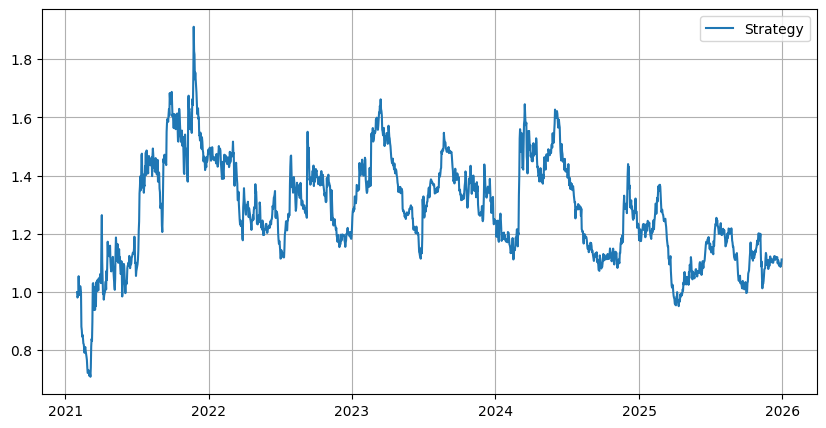

In [92]:
port = pd.DataFrame(portfolio_hist)

# btc_ret = rts['BTC'].reindex(pd.DatetimeIndex(port['date']))
# btc_eq = (1 + btc_ret).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(port['date'], port['nav'], label='Strategy')
# plt.plot(port['date'], btc_eq, label='Bitcoin', linestyle='--', alpha=0.7)
plt.legend()
plt.grid()
plt.show()


In [93]:
compute_metrics(port)

{'total_return': '11.12%',
 'long_return': np.float64(0.055828603799605525),
 'short_return': np.float64(0.009306147160529042),
 'annualized_return': '2.17%',
 'annualized_volatility': '43.41%',
 'sharpe_ratio': '0.05',
 'sortino_ratio': '0.09',
 'max_drawdown': '-50.27%',
 'max_dd_date': '2025-04-12',
 'calmar_ratio': '0.04',
 'daily_win_rate': '47.35%',
 'final_nav': '$1.11',
 'avg_net_exposure': '$-0',
 'avg_gross_exposure': '$1',
 'total_days': 1794}

## Simplified Backtest (vectorized)

In [262]:
complete_df

,date,coin_id,market_cap,volume,rank,symbol,rvol,open,high,low,close,volume_binance,quote_volume,trades
0,2021-01-01,bitcoin,5.394380e+11,4.350352e+10,1,BTC,NaN,28923.63000,29600.0000,28624.5700,29331.69000,5.418293e+04,1.582527e+09,1314910
1,2021-01-01,ethereum,8.403769e+10,1.816611e+10,2,ETH,NaN,736.42000,749.0000,714.2900,728.91000,6.751141e+05,4.960720e+08,483671
2,2021-01-01,ripple,9.986921e+09,4.364513e+09,4,XRP,NaN,0.21953,0.2500,0.2160,0.23746,1.490490e+09,3.517304e+08,652631
3,2021-01-01,polkadot,8.790589e+09,1.926142e+09,5,DOT,NaN,9.26200,9.4280,8.0729,8.27760,4.044497e+07,3.532333e+08,520258
4,2021-01-01,litecoin,8.232940e+09,4.978856e+09,6,LTC,NaN,124.22000,133.9700,122.8900,126.24000,1.539802e+06,1.975562e+08,349403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190282,2025-12-30,pyth-network,3.368279e+08,1.469403e+07,192,PYTH,0.648621,0.05870,0.0594,0.0579,0.05860,1.451477e+07,8.520381e+05,9434
190283,2025-12-30,gnosis,3.327784e+08,7.126789e+06,195,GNO,0.755920,126.14000,132.3700,125.2000,127.21000,1.898139e+03,2.421694e+05,8140
190284,2025-12-30,plasma,3.286698e+08,1.208724e+08,197,XPL,0.958907,0.15840,0.1648,0.1485,0.16410,9.774413e+07,1.507176e+07,129134
190285,2025-12-30,decred,3.268343e+08,4.829011e+06,199,DCR,1.754590,19.02000,19.2400,18.2400,18.73000,3.116355e+04,5.817903e+05,12647


In [263]:
# Map Binance pair names → base symbol so columns match top_200_filtered symbols
# pair_to_base = {info['symbol']: base for base, info in universe.items()}
# price_df = binance_px.rename(columns=pair_to_base)
# price_df = price_df.rename(columns={'FTMUSDT': 'FTM'})
price_table = complete_df.pivot_table(values='close', index='date', columns='symbol')

# Pivot rvol into a date × symbol table (filtered universe only)
rvol_table = complete_df.pivot_table(values='rvol', index='date', columns='symbol')

In [264]:
binance_vols = complete_df['quote_volume'].quantile(0.25)
coingecko_vols = complete_df['volume'].quantile(0.25)

binance_vols, coingecko_vols

(np.float64(3993031.6139169997), np.float64(25160479.31301365))

In [295]:
K = 5

volume_table = complete_df.pivot_table(values='quote_volume', index='date', columns='symbol')

signal = {}
for date, row in rvol_table.iterrows():
    clean = row.dropna()
    if date in volume_table.index:
        volume_row = volume_table.loc[date]
        clean = clean[clean.index.isin(
                volume_row[volume_row >= binance_vols].index
                )]
    if clean.notna().sum() >= 10:
        top = clean.nlargest(K)
        bot = clean.nsmallest(K)
        signal[date] = {
            'top': list(top.index),
            'bot': list(bot.index)
        }

In [266]:
volume_binance = pd.pivot_table(complete_df, values="quote_volume", index="date", columns="symbol")
short_sma= volume_binance.rolling(SHORT_SMA).mean()
long_sma = volume_binance.rolling(LONG_SMA).mean()
rvol_binance = short_sma / long_sma
rvol_bnbn_lookup = rvol_binance.stack().rename("rvol_binance").reset_index()
rvol_bnbn_lookup.columns = ["date", "symbol", "rvol_binance"]
if 'rvol_binance' not in complete_df.columns:
    complete_df = complete_df.merge(
        rvol_bnbn_lookup,
        on=["date", "symbol"],
        how="left"
    )

rvol_bnb_table = complete_df.pivot_table(values='rvol_binance', index='date', columns='symbol')

Same as above BUT using only Binance Data to calculate RVOL

<div class="alert alert-block alert-warning">
<b>TODO:</b> Coin selection (top 200) is still done with Coingecko marketcap data
</div>

In [283]:
K = 5

signal = {}
for date, row in rvol_bnb_table.iterrows():
    clean = row.dropna()
    # if date in volume_table.index:
    #     volume_row = volume_table.loc[date]
    #     clean = clean[clean.index.isin(
    #             volume_row[volume_row >= binance_vols].index
    #             )]
    if clean.notna().sum() >= 10:
        top = clean.nlargest(K)
        bot = clean.nsmallest(K)
        signal[date] = {
            'top': list(top.index),
            'bot': list(bot.index)
        }

In [268]:
# Forward returns: today's close → tomorrow's close (shift(-1) = next row)
rts = price_table.pct_change().shift(-1)

/var/folders/vy/wx4s8rtd79n9d9lh1qlpfmh00000gn/T/ipykernel_34555/2992480339.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rts = price_table.pct_change().shift(-1)


In [296]:
strat = {}
strat_net = {}
strat_net_long = {}

problematic_dates = []

prev_weights = pd.Series(0.0, index=rts.columns)
prev_weights_long = pd.Series(0.0, index=rts.columns)

for date, row in rts.iterrows():
    selection = signal.get(date, None)
    
    if selection is None:
        problematic_dates.append(date)
        continue

    top_avail = [s for s in selection['top'] if s in row.index and pd.notna(row.get(s))]
    bot_avail = [s for s in selection['bot'] if s in row.index and pd.notna(row.get(s))]
    if not top_avail or not bot_avail:
        print(f"Something went wrong on {date}")
        problematic_dates.append(date)
        continue

    if len(top_avail) < 5:
        print("Less then expected")

    weights = pd.Series(0.0, index=row.index)
    weights_long = pd.Series(0.0, index=row.index)

    weights_long[top_avail] = 1 / len(top_avail)
    weights[top_avail] = 1 / len(top_avail)
    if bot_avail:
        weights[bot_avail] = -1 / len(bot_avail)

    gross_return = (weights * row).sum()
    turnover = (weights - prev_weights).abs().sum()
    net_return = gross_return - turnover * FEE_RATE

    gross_return_long = (weights_long * row).sum()
    turnover_long = (weights_long - prev_weights_long).abs().sum()
    net_return_long = gross_return_long - turnover_long * FEE_RATE

    strat[date] = gross_return
    strat_net[date] = net_return
    strat_net_long[date] = net_return_long

    prev_weights = weights
    prev_weights_long = weights_long

strat = pd.Series(strat)
strat_net = pd.Series(strat_net)
strat_net_long = pd.Series(strat_net_long)

Something went wrong on 2025-12-30 00:00:00


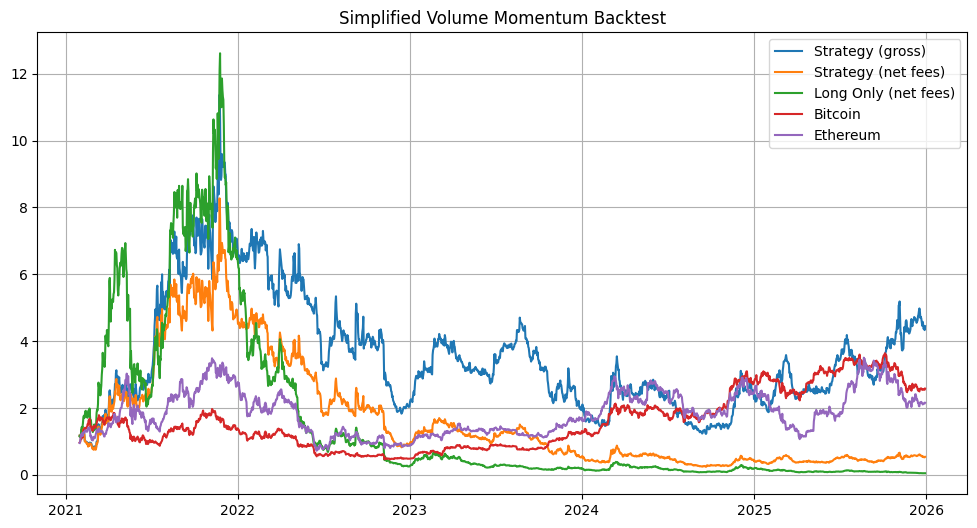

In [297]:
equity = (strat + 1).cumprod()
equity_net = (strat_net + 1).cumprod()
equity_net_long = (strat_net_long + 1).cumprod()

btc_ret = rts['BTC'].reindex(equity.index)
btc_eq = (1 + btc_ret).cumprod()
eth_ret = rts['ETH'].reindex(equity.index)
eth_eq = (1 + eth_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(equity, label='Strategy (gross)')
plt.plot(equity_net, label='Strategy (net fees)')
plt.plot(equity_net_long, label='Long Only (net fees)')
plt.plot(btc_eq, label='Bitcoin')
plt.plot(eth_eq, label='Ethereum')
plt.legend()
plt.grid()
plt.title('Simplified Volume Momentum Backtest')
plt.show()

In [298]:
def backtest_metrics(returns, label=""):
    eq = (1 + returns).cumprod()
    n = len(returns)
    ann_ret = eq.iloc[-1] ** (365 / n) - 1
    ann_vol = returns.std() * np.sqrt(365)
    drawdown = (eq / eq.cummax()) - 1
    max_dd = drawdown.min()
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return {
        "Strategy": label,
        "Ann. Return": f"{ann_ret:.2%}",
        "Ann. Volatility": f"{ann_vol:.2%}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Sharpe": f"{sharpe:.2f}",
    }

rows = [
    backtest_metrics(strat,          "Gross L/S"),
    backtest_metrics(strat_net,      "Net L/S"),
    backtest_metrics(strat_net_long, "Net Long Only"),
    backtest_metrics(rts['BTC'].reindex(strat.index).dropna(), "Bitcoin"),
    backtest_metrics(rts['ETH'].reindex(strat.index).dropna(), "Ethereum"),
]

pd.DataFrame(rows).set_index("Strategy")

,Ann. Return,Ann. Volatility,Max Drawdown,Sharpe
Strategy,,,,
Gross L/S,35.46%,90.83%,-89.22%,0.39
Net L/S,-11.85%,90.83%,-97.07%,-0.13
Net Long Only,-45.75%,114.38%,-99.62%,-0.40
Bitcoin,21.28%,57.51%,-76.63%,0.37
Ethereum,16.93%,76.94%,-79.30%,0.22


### Diagnostics

In [287]:
# Annual breakdown — pinpoints which year the strategy breaks
annual = pd.DataFrame({
    'gross':     strat.resample('YE').apply(lambda r: (1 + r).prod() - 1),
    'net':       strat_net.resample('YE').apply(lambda r: (1 + r).prod() - 1),
    'long_only': strat_net_long.resample('YE').apply(lambda r: (1 + r).prod() - 1),
    'btc':       rts['BTC'].reindex(strat.index).resample('YE').apply(lambda r: (1 + r).prod() - 1),
})
annual.index = annual.index.year
annual.style.format("{:.2%}")

,gross,net,long_only,btc
2021,84.77%,34.14%,514.45%,39.28%
2022,-88.65%,-92.06%,-97.24%,-65.18%
2023,-50.83%,-65.85%,-29.75%,165.87%
2024,-1.80%,-29.58%,-31.71%,114.11%
2025,130.77%,66.83%,-56.56%,-6.46%


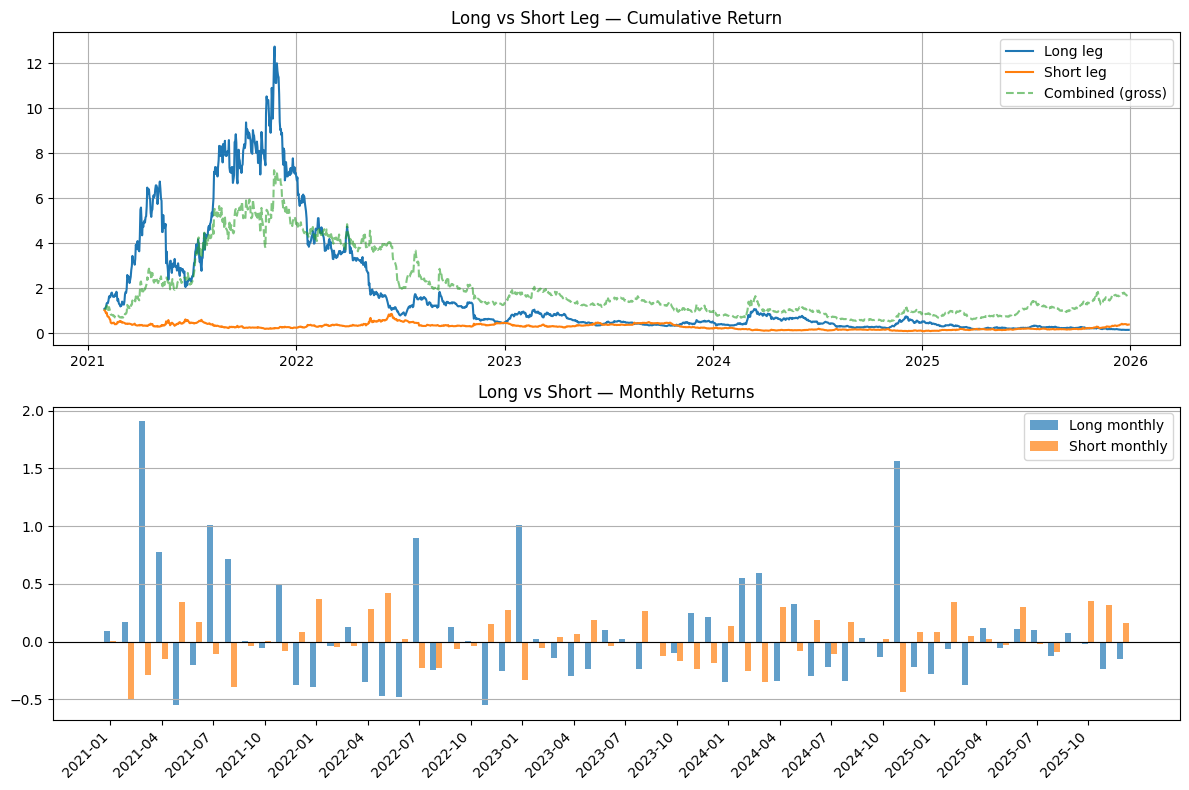

In [192]:
# Long vs short leg attribution — which side is causing the crash?
long_daily = {}
short_daily = {}

for date, row in rts.iterrows():
    sel = signal.get(date)
    if sel is None:
        continue
    
    top_avail = [s for s in sel['top'] if s in row.index and pd.notna(row.get(s))]
    bot_avail = [s for s in sel['bot'] if s in row.index and pd.notna(row.get(s))]
    if top_avail:
        long_daily[date] = row[top_avail].mean()
    if bot_avail:
        short_daily[date] = -row[bot_avail].mean()

long_s = pd.Series(long_daily)
short_s = pd.Series(short_daily)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot((1 + long_s).cumprod(),  label='Long leg')
axes[0].plot((1 + short_s).cumprod(), label='Short leg')
axes[0].plot((1 + strat).cumprod(),   label='Combined (gross)', linestyle='--', alpha=0.6)
axes[0].set_title('Long vs Short Leg — Cumulative Return')
axes[0].legend()
axes[0].grid()

long_m  = long_s.resample('ME').apply(lambda r: (1 + r).prod() - 1)
short_m = short_s.resample('ME').apply(lambda r: (1 + r).prod() - 1)
x = np.arange(len(long_m))
w = 0.35
axes[1].bar(x - w/2, long_m.values,  w, label='Long monthly',  alpha=0.7)
axes[1].bar(x + w/2, short_m.values, w, label='Short monthly', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels(long_m.index[::3].strftime('%Y-%m'), rotation=45, ha='right')
axes[1].set_title('Long vs Short — Monthly Returns')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

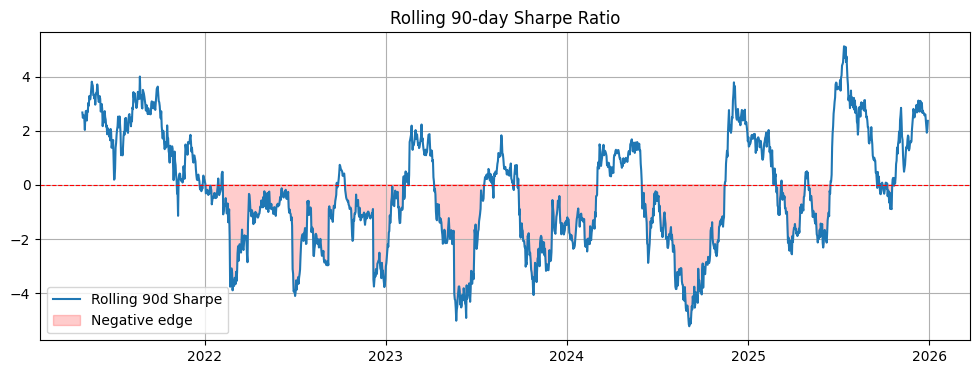

Most frequently longed:
PAXG     158
STX      132
TFUEL    129
GNO      125
XEC      115
TWT      105
DCR      102
AXS       99
SC        97
HBAR      96

Most frequently shorted:
XEC      208
SC       196
TFUEL    196
DCR      187
STX      162
ICX      136
HIVE     133
GLM      133
AMP      129
IOTX     128


In [193]:
# Rolling 90-day Sharpe — shows exactly when the edge disappears
rolling_sharpe = strat_net.rolling(90).apply(
    lambda r: (r.mean() / r.std()) * np.sqrt(365) if r.std() > 0 else np.nan
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_sharpe, label='Rolling 90d Sharpe')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                where=(rolling_sharpe < 0), alpha=0.2, color='red', label='Negative edge')
ax.set_title('Rolling 90-day Sharpe Ratio')
ax.legend()
ax.grid()
plt.show()

# Most frequently selected coins — sanity check on signal concentration
from collections import Counter
long_counts  = Counter(s for v in signal.values() for s in v['top'])
short_counts = Counter(s for v in signal.values() for s in v['bot'])

print("Most frequently longed:")
print(pd.Series(long_counts).nlargest(10).to_string())
print("\nMost frequently shorted:")
print(pd.Series(short_counts).nlargest(10).to_string())

## Fit Parameters

In [337]:
_rvol_cache = {}

def compute_rvol_table(short_sma, long_sma):
    key = (short_sma, long_sma)
    if key not in _rvol_cache:
        short_ma = volume_table.rolling(short_sma).mean()
        long_ma  = volume_table.rolling(long_sma).mean()
        lookup = (short_ma / long_ma).stack().rename("rvol_fit").reset_index()
        lookup.columns = ["date", "symbol", "rvol_fit"]
        merged = complete_df.merge(lookup, on=["date", "symbol"], how="left")
        _rvol_cache[key] = merged.pivot_table(values="rvol_fit", index="date", columns="symbol")
    return _rvol_cache[key]


In [343]:
volume_table = complete_df.pivot_table(values='volume', index='date', columns='symbol')

In [291]:
def run_backtest(short_sma, long_sma, k, holding_days, fee_rate=FEE_RATE):
    rvol_tbl   = compute_rvol_table(short_sma, long_sma)
    all_dates  = list(rts.index)
    rebal_set  = set(all_dates[::holding_days])

    returns = {}
    weights = pd.Series(0.0, index=rts.columns)

    for date, row in rts.iterrows():
        turnover = 0.0
        if date in rebal_set and date in rvol_tbl.index:
            clean = rvol_tbl.loc[date].dropna()
            clean = clean.reindex(row.dropna().index).dropna()
            if len(clean) >= k * 2:
                top_syms = clean.nlargest(k).index.tolist()
                bot_syms = [s for s in clean.nsmallest(k).index if s not in top_syms]
                new_w = pd.Series(0.0, index=rts.columns)
                if top_syms: new_w[top_syms] =  1.0 / len(top_syms)
                if bot_syms: new_w[bot_syms] = -1.0 / len(bot_syms)
                turnover = (new_w - weights).abs().sum()
                weights  = new_w

        returns[date] = (weights * row).sum() - turnover * fee_rate

    s = pd.Series(returns).dropna()
    if len(s) < 60:
        return None

    eq      = (1 + s).cumprod()
    n       = len(s)
    ann_ret = eq.iloc[-1] ** (365 / n) - 1
    ann_vol = s.std() * np.sqrt(365)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = ((eq / eq.cummax()) - 1).min()

    return dict(short_sma=short_sma, long_sma=long_sma, k=k, holding_days=holding_days,
                ann_return=ann_ret, ann_vol=ann_vol, sharpe=sharpe, max_dd=max_dd)


In [338]:
def run_backtest(short_sma, long_sma, k, holding_days, fee_rate=FEE_RATE):
    rvol_tbl = compute_rvol_table(short_sma, long_sma)

    # Step 1: generate a full-weight signal for EVERY date
    signals = {}
    for date, row in rts.iterrows():
        if date not in rvol_tbl.index:
            continue
        clean = rvol_tbl.loc[date].dropna().reindex(row.dropna().index).dropna()

        # if min_volume > 0 and date in volume_table.index:
        #     volume_row = volume_table.loc[date]
        #     clean = clean[clean.index.isin(
        #             volume_row[volume_row >= min_volume].index
        #             )]

        if len(clean) < k * 2:
            continue
        top = clean.nlargest(k).index.tolist()
        bot = [s for s in clean.nsmallest(k).index if s not in top]
        w = pd.Series(0.0, index=rts.columns)
        if top: w[top] =  1.0 / len(top)
        if bot: w[bot] = -1.0 / len(bot)
        signals[date] = w

    if not signals:
        return None

    # Step 2: portfolio weights = rolling average of last `holding_days` signals
    #         → naturally creates holding_days overlapping equal-weight cohorts
    signal_df = pd.DataFrame(signals).T.sort_index()
    combined  = signal_df.rolling(window=holding_days, min_periods=1).mean()

    # Step 3: vectorized PnL
    rt       = rts.reindex(index=combined.index, columns=combined.columns).fillna(0)
    gross    = (combined * rt).sum(axis=1)
    turnover = combined.diff().abs().sum(axis=1)
    turnover.iloc[0] = combined.iloc[0].abs().sum()  # first day: full entry cost
    net = gross - turnover * fee_rate

    if len(net) < 60:
        return None

    eq      = (1 + net).cumprod()
    n       = len(net)
    ann_ret = eq.iloc[-1] ** (365 / n) - 1
    ann_vol = net.std() * np.sqrt(365)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = ((eq / eq.cummax()) - 1).min()
    downside = net[net < 0].std() * np.sqrt(365)
    sortino  = ann_ret / downside if downside > 0 else np.nan

    return dict(short_sma=short_sma, long_sma=long_sma, k=k, holding_days=holding_days,
                ann_return=ann_ret, ann_vol=ann_vol, sharpe=sharpe, sortino=sortino, max_dd=max_dd)


In [339]:
from itertools import product
import multiprocessing as mp
from joblib import Parallel, delayed


# param_grid = {
#     'short_sma':    [3, 5, 7, 10],
#     'long_sma':     [20, 30, 45, 60],
#     'k':            [3, 5, 7, 10],
#     'holding_days': [1, 3, 5, 10],
# }

param_grid = { # multiples of 7
    'short_sma':    [3, 5, 7, 10, 14],
    'long_sma':     [21, 28, 35, 42, 49],
    'k':            [3, 5, 7, 10],
    'holding_days': [1, 3, 5, 7, 10, 14],
}

combos = [
    (ss, ls, k, hd)
    for ss, ls, k, hd in product(
        param_grid['short_sma'], param_grid['long_sma'],
        param_grid['k'],         param_grid['holding_days'],
    )
    if ss < ls  # sanity: short window must be shorter
]

combos_sorted = sorted(combos, key=lambda x: (x[0], x[1]))

# unique_sma = {(ss, ls) for ss, ls, *_ in combos}
# for ss, ls in tqdm(unique_sma, desc="Precomputing rvol tables"):
#     compute_rvol_table(ss, ls)

# results = []
# for params in tqdm(combos, desc="Grid search"):
#     r = run_backtest(*params)
#     if r:
#         results.append(r)

# with mp.Pool() as pool:
#     results_raw = list(tqdm(
#         pool.starmap(run_backtest, combos),
#         total=len(combos),
#         desc="Grid search",
#     ))

# results = [r for r in results_raw if r is not None]

results = Parallel(n_jobs=-1)(
    delayed(run_backtest)(*p) for p in tqdm(combos_sorted, desc="Grid search")
)
results = [r for r in results if r is not None]

results_df = pd.DataFrame(results).sort_values('sharpe', ascending=False).reset_index(drop=True)
results_df.head(20).style.format({
    'ann_return': '{:.2%}', 'ann_vol': '{:.2%}',
    'sharpe': '{:.2f}',     'max_dd': '{:.2%}',
})


Grid search:   0%|          | 0/600 [00:00<?, ?it/s]

Grid search: 100%|██████████| 600/600 [06:12<00:00,  1.61it/s]


,short_sma,long_sma,k,holding_days,ann_return,ann_vol,sharpe,sortino,max_dd
0,3,28,10,14,29.40%,34.62%,0.85,1.308315,-35.73%
1,3,28,10,10,31.92%,38.82%,0.82,1.283075,-40.45%
2,3,28,10,5,36.77%,45.72%,0.80,1.357211,-57.54%
3,5,28,10,14,28.81%,36.07%,0.80,1.228310,-33.91%
4,10,28,10,3,40.13%,50.86%,0.79,1.292109,-52.39%
5,3,28,7,5,42.46%,55.08%,0.77,1.326183,-62.43%
6,3,28,7,14,30.69%,40.68%,0.75,1.168287,-38.48%
7,5,28,10,3,37.50%,50.86%,0.74,1.248392,-53.39%
8,3,42,10,14,26.23%,35.75%,0.73,1.226674,-47.27%
9,7,28,10,3,36.72%,50.54%,0.73,1.204912,-54.50%


In [341]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize each metric (higher is better for sharpe/sortino, lower for drawdown)
results_df["score"] = (
    scaler.fit_transform(results_df[["sharpe"]]) * 0.4 +
    scaler.fit_transform(results_df[["sortino"]]) * 0.4 +
    (1 - scaler.fit_transform(results_df[["max_dd"]])) * 0.2  # invert drawdown
).squeeze()

results_df.sort_values("score", ascending=False).head(20).style \
    .background_gradient(subset=["sharpe", "sortino"], cmap="Greens") \
    .background_gradient(subset=["max_dd"], cmap="Reds_r") \
    .background_gradient(subset=["score"], cmap="Blues") \
    .format(precision=4)

,short_sma,long_sma,k,holding_days,ann_return,ann_vol,sharpe,sortino,max_dd,score
2,3,28,10,5,0.3677,0.4572,0.8042,1.3572,-0.5754,0.8645
5,3,28,7,5,0.4246,0.5508,0.7709,1.3262,-0.6243,0.8641
4,10,28,10,3,0.4013,0.5086,0.7891,1.2921,-0.5239,0.8336
26,14,49,10,1,0.3357,0.5300,0.6335,1.0628,-0.7659,0.8205
21,3,28,7,3,0.3865,0.5995,0.6447,1.1051,-0.7194,0.8176
7,5,28,10,3,0.3750,0.5086,0.7373,1.2484,-0.5339,0.8145
43,5,49,10,1,0.3090,0.5609,0.5508,0.9755,-0.8715,0.8130
32,3,28,5,3,0.4184,0.7127,0.5871,1.0357,-0.7837,0.8080
9,7,28,10,3,0.3672,0.5054,0.7265,1.2049,-0.5450,0.8070
1,3,28,10,10,0.3192,0.3882,0.8223,1.2831,-0.4045,0.8063


In [344]:
def diagnose_signals(rvol_tbl, rts, vol_table, k, min_volume=0):
    rows = []
    for date, ret_row in rts.iterrows():
        r = {'date': date}

        # Check 1: rvol coverage
        if date not in rvol_tbl.index:
            r['status'] = 'NO_RVOL_DATE'
            rows.append(r)
            continue

        rvol_row = rvol_tbl.loc[date]
        r['n_rvol']  = rvol_row.notna().sum()

        # Check 2: return coverage
        ret_avail = ret_row.dropna()
        r['n_returns'] = len(ret_avail)

        # Check 3: overlap after intersection
        clean = rvol_row.dropna().reindex(ret_avail.index).dropna()
        r['n_overlap'] = len(clean)

        # Check 4: volume filter impact
        if min_volume > 0 and date in vol_table.index:
            vol_row = vol_table.loc[date]
            clean_vol = clean[clean.index.isin(vol_row[vol_row >= min_volume].index)]
            r['n_after_vol_filter'] = len(clean_vol)
        else:
            r['n_after_vol_filter'] = len(clean)

        # Verdict
        if r['n_returns'] == 0:
            r['status'] = 'NO_RETURNS'
        elif r['n_overlap'] < k * 2:
            r['status'] = 'INSUFFICIENT_OVERLAP'
        elif r['n_after_vol_filter'] < k * 2:
            r['status'] = 'VOL_FILTER_TOO_STRICT'
        else:
            r['status'] = 'OK'

        rows.append(r)

    diag = pd.DataFrame(rows).set_index('date')
    return diag


diag = diagnose_signals(rvol_table, rts, volume_table, k=K, min_volume=0)

print(diag['status'].value_counts())
print(f"\nSkipped dates: {(diag['status'] != 'OK').sum()} / {len(diag)}")
print(f"\nOn OK dates:")
print(diag[diag['status'] == 'OK'][['n_rvol', 'n_returns', 'n_overlap']].describe().loc[['min', 'mean', 'max']].round(1))


status
OK              1795
NO_RVOL_DATE      29
NO_RETURNS         1
Name: count, dtype: int64

Skipped dates: 30 / 1825

On OK dates:
      n_rvol  n_returns  n_overlap
min     78.0       86.0       78.0
mean   103.6      187.1      103.6
max    123.0      269.0      123.0


In [321]:
results_df

,short_sma,long_sma,k,holding_days,ann_return,ann_vol,sharpe,max_dd
0,14,28,10,14,0.308155,0.387773,0.794679,-0.350453
1,14,49,10,5,0.388650,0.493323,0.787821,-0.613326
2,14,42,10,14,0.316076,0.404506,0.781387,-0.457766
3,14,49,10,7,0.364842,0.472241,0.772576,-0.547371
4,3,42,10,14,0.282435,0.375027,0.753106,-0.569382
...,...,...,...,...,...,...,...,...
595,7,21,3,14,NaN,0.798674,NaN,-1.291647
596,10,21,3,5,NaN,1.005573,NaN,-1.129292
597,10,21,3,7,NaN,0.969182,NaN,-1.273592
598,10,21,3,10,NaN,0.896018,NaN,-1.292915


In [319]:
results_df

,short_sma,long_sma,k,holding_days,ann_return,ann_vol,sharpe,max_dd
0,10,45,10,10,0.268485,0.440858,0.609005,-0.533351
1,10,30,10,10,0.258984,0.435486,0.594700,-0.588804
2,7,30,7,10,0.281905,0.506582,0.556485,-0.562850
3,5,45,7,10,0.278470,0.504754,0.551695,-0.709466
4,10,45,10,5,0.267142,0.501613,0.532566,-0.606383
...,...,...,...,...,...,...,...,...
251,3,20,3,10,NaN,0.800918,NaN,-1.106121
252,5,20,3,10,NaN,0.835768,NaN,-1.017269
253,7,20,3,5,NaN,1.009130,NaN,-1.132963
254,7,20,3,10,NaN,0.885007,NaN,-1.363156


## Rolling-Cohort Long-Short Backtest

Every day opens a new **cohort**: long top-N by market cap, short bottom-N.  
Each cohort holds for `HOLDING_DAYS` and gets `1/HOLDING_DAYS` of NAV.  
At steady state there are `HOLDING_DAYS` overlapping cohorts, smoothing turnover and entry-price luck.

In [378]:
class CohortConfig:
    HOLDING_DAYS    = 5
    LONG_SIZE       = 5
    SHORT_SIZE      = 5
    INITIAL_CAPITAL = 100_000
    LONG_ALLOC_PCT  = 0.50
    SHORT_ALLOC_PCT = 0.50

    SPOT_FEE_BPS       = 10
    SPOT_SLIP_BPS      = 5
    FUT_FEE_BPS        = 4
    FUT_SLIP_BPS       = 5
    DELIST_PENALTY_BPS = 500
    MARGIN_PCT         = 0.10

    MIN_VOLUME_USD   = 1_000_000
    MIN_LISTING_DAYS = 30
    FUND_RATE_DAILY  = 0.10 / 365

    BACKTEST_START = "2021-01-01"
    BACKTEST_END   = "2025-12-31"


In [379]:
class Cohort:
    _counter = 0

    def __init__(self, open_date, close_date, capital):
        Cohort._counter += 1
        self.id         = Cohort._counter
        self.open_date  = open_date
        self.close_date = close_date
        self.capital    = capital
        self.longs      = {}   # symbol -> Position
        self.shorts     = {}   # symbol -> Position
        self.closed     = False
        self.realized_pnl     = 0.0
        self.fees_paid        = 0.0
        self.funding_received = 0.0

    def nav(self, price_fn):
        v = 0.0
        for sym, pos in self.longs.items():
            p = price_fn(sym)
            if p: v += pos.market_value(p)
        for sym, pos in self.shorts.items():
            p = price_fn(sym)
            if p: v += pos.margin_posted + pos.unrealized_pnl(p) + pos.cumulative_funding
        return v

In [ ]:
class CohortEngine:
    def __init__(self, cfg: CohortConfig, price_tbl, vol_tbl, rvol_tbl, univ):
        self.cfg  = cfg
        self.pt   = price_tbl  # date × symbol pivot of Binance close
        self.vt   = vol_tbl    # date × symbol pivot of Binance quote_volume
        self.rvol = rvol_tbl   # date × symbol pivot of relative-volume signal (T-1 used for ranking)
        self.univ = univ       # universe dict {base: {first_available_date_after_backtest_start, delisted_date, ...}}

        c = cfg
        self.spot_fee  = c.SPOT_FEE_BPS       / 10_000
        self.spot_slip = c.SPOT_SLIP_BPS       / 10_000
        self.fut_fee   = c.FUT_FEE_BPS         / 10_000
        self.fut_slip  = c.FUT_SLIP_BPS        / 10_000
        self.penalty   = c.DELIST_PENALTY_BPS  / 10_000

    # ── price lookup ──────────────────────────────────────────────────
    def _price(self, sym, date):
        try:
            p = self.pt.at[date, sym]
            return float(p) if pd.notna(p) else None
        except (KeyError, TypeError):
            return None

    # ── tradability ───────────────────────────────────────────────────
    def _tradable(self, sym, date):
        if sym not in self.univ:
            return False
        info     = self.univ[sym]
        listed   = pd.Timestamp(info['first_available_date_after_backtest_start'])
        dl_str   = info.get('delisted_date')
        delisted = pd.Timestamp(dl_str) if dl_str else pd.Timestamp('2030-01-01')
        if date < listed or date > delisted:
            return False
        if (date - listed).days < self.cfg.MIN_LISTING_DAYS:
            return False
        try:
            vol = self.vt.at[date, sym]
            if pd.isna(vol) or vol < self.cfg.MIN_VOLUME_USD:
                return False
        except (KeyError, TypeError):
            return False
        return True

    # ── trade helpers ─────────────────────────────────────────────────
    def _open_long(self, sym, capital, price):
        buy  = price * (1 + self.spot_slip)
        fee  = capital * self.spot_fee
        shrs = (capital - fee) / buy
        return Position(sym, shrs, buy, "long"), fee

    def _open_short(self, sym, notional, price):
        entry  = price * (1 + self.fut_slip)
        shrs   = notional / entry
        margin = notional * self.cfg.MARGIN_PCT
        fee    = notional * self.fut_fee
        pos    = Position(sym, shrs, entry, "short", margin_posted=margin)
        return pos, margin + fee, fee

    def _close_long(self, pos, price):
        sell  = price * (1 - self.spot_slip)
        gross = pos.shares * sell
        fee   = gross * self.spot_fee
        return gross - fee, fee
    
    def _close_short(self, pos, price):
        cover = price * (1 + self.fut_slip)
        pnl   = pos.shares * (pos.entry_price - cover)
        fee   = pos.shares * cover * self.fut_fee
        cash  = pos.margin_posted + pnl + pos.cumulative_funding - fee
        return cash, fee

    # ── cohort lifecycle ──────────────────────────────────────────────
    def _open_cohort(self, date, all_dates, prev_date, cohort_capital):
        cfg = self.cfg
        di        = all_dates.index(date)
        close_idx = min(di + cfg.HOLDING_DAYS, len(all_dates) - 1)
        cohort    = Cohort(date, all_dates[close_idx], cohort_capital)

        # T-1 rvol ranking — no look-ahead
        if prev_date not in self.rvol.index:
            return cohort, 0.0

        rvol_row = self.rvol.loc[prev_date].dropna()
        tradable = rvol_row[[s for s in rvol_row.index if self._tradable(s, date)]]

        if len(tradable) < cfg.LONG_SIZE + cfg.SHORT_SIZE:
            return cohort, 0.0

        long_syms  = list(tradable.nlargest(cfg.LONG_SIZE).index)
        short_syms = [s for s in tradable.nsmallest(cfg.SHORT_SIZE).index if s not in long_syms]

        per_long  = (cohort_capital * cfg.LONG_ALLOC_PCT)  / max(len(long_syms),  1)
        per_short = (cohort_capital * cfg.SHORT_ALLOC_PCT) / max(len(short_syms), 1)
        cash_used = 0.0

        for sym in long_syms:
            p = self._price(sym, date)
            if not p: continue
            pos, fee = self._open_long(sym, per_long, p)
            cohort.longs[sym] = pos
            cohort.fees_paid  += fee
            cash_used         += per_long

        for sym in short_syms:
            p = self._price(sym, date)
            if not p: continue
            pos, cost, fee     = self._open_short(sym, per_short, p)
            cohort.shorts[sym] = pos
            cohort.fees_paid  += fee
            cash_used         += cost

        return cohort, cash_used

    def _close_cohort(self, cohort, date):
        cash = 0.0
        for sym in list(cohort.longs):
            p = self._price(sym, date)
            if p:
                proceeds, fee = self._close_long(cohort.longs[sym], p)
                cash += proceeds
                cohort.fees_paid    += fee
                cohort.realized_pnl += cohort.longs[sym].unrealized_pnl(p)
            del cohort.longs[sym]
        for sym in list(cohort.shorts):
            p = self._price(sym, date)
            if p:
                proceeds, fee = self._close_short(cohort.shorts[sym], p)
                cash += proceeds
                cohort.fees_paid        += fee
                cohort.realized_pnl     += cohort.shorts[sym].unrealized_pnl(p)
                cohort.funding_received += cohort.shorts[sym].cumulative_funding
            del cohort.shorts[sym]
        cohort.closed = True
        return cash

    def _handle_delistings(self, cohort, date):
        delta = 0.0
        for sym in list(cohort.longs):
            dl = self.univ.get(sym, {}).get('delisted_date')
            if dl and date >= pd.Timestamp(dl):
                p = self._price(sym, date)
                if p:
                    ep = p * (1 - self.penalty)
                    proceeds, fee = self._close_long(cohort.longs[sym], ep)
                    delta += proceeds; cohort.fees_paid += fee
                    print(f"  \u26a0 DELIST long  {sym}  cohort#{cohort.id}")
                del cohort.longs[sym]
        for sym in list(cohort.shorts):
            dl = self.univ.get(sym, {}).get('delisted_date')
            if dl and date >= pd.Timestamp(dl):
                p = self._price(sym, date)
                if p:
                    pos   = cohort.shorts[sym]
                    cover = p * (1 + self.penalty)
                    pnl   = pos.shares * (pos.entry_price - cover)
                    delta += pos.margin_posted + pnl + pos.cumulative_funding
                    print(f"  \u26a0 DELIST short {sym}  cohort#{cohort.id}")
                del cohort.shorts[sym]
        return delta

    def _apply_funding(self, cohort):
        total = 0.0
        for pos in cohort.shorts.values():
            payment = pos.shares * pos.entry_price * self.cfg.FUND_RATE_DAILY
            pos.cumulative_funding += payment
            total += payment
        return total

    # ── main loop ─────────────────────────────────────────────────────
    def run(self):
        cfg = self.cfg
        # all_dates comes from rvol index — only dates with a valid signal
        all_dates = sorted(self.rvol.index)
        all_dates = [d for d in all_dates
                     if cfg.BACKTEST_START <= d.strftime('%Y-%m-%d') <= cfg.BACKTEST_END]

        cash      = cfg.INITIAL_CAPITAL
        active    = []
        closed    = []
        history   = []
        trade_log = []

        print(f"{'─'*60}")
        print(f"  Rolling-Cohort L/S  {cfg.BACKTEST_START} \u2192 {cfg.BACKTEST_END}")
        print(f"  Signal: RVOL  |  Hold {cfg.HOLDING_DAYS}d  |  K={cfg.LONG_SIZE} per side")
        print(f"  Capital ${cfg.INITIAL_CAPITAL:,}  |  Margin {cfg.MARGIN_PCT:.0%}")
        print(f"{'─'*60}")

        for di, date in enumerate(all_dates):
            price_fn = lambda s, d=date: self._price(s, d)

            # 1. delistings
            for c in active:
                cash += self._handle_delistings(c, date)

            # 2. funding on all active short legs
            daily_fund = 0.0
            for c in active:
                f = self._apply_funding(c)
                cash += f; daily_fund += f

            # 3. close expired cohorts
            still_active = []
            for c in active:
                if date >= c.close_date:
                    cash += self._close_cohort(c, date)
                    closed.append(c)
                    trade_log.append(dict(date=date, action='CLOSE', cohort_id=c.id,
                                          realized_pnl=round(c.realized_pnl, 2),
                                          fees=round(c.fees_paid, 2)))
                else:
                    still_active.append(c)
            active = still_active

            # 4. open new cohort sized at 1/HOLDING_DAYS of NAV
            nav        = cash + sum(c.nav(price_fn) for c in active)
            cohort_cap = nav / cfg.HOLDING_DAYS
            max_cash   = (cohort_cap * cfg.LONG_ALLOC_PCT +
                          cohort_cap * cfg.SHORT_ALLOC_PCT * cfg.MARGIN_PCT +
                          cohort_cap * 0.005)
            if max_cash > cash * 0.98:
                cohort_cap = cash * 0.98 / (
                    cfg.LONG_ALLOC_PCT + cfg.SHORT_ALLOC_PCT * cfg.MARGIN_PCT + 0.005)

            prev_date = all_dates[max(di - 1, 0)]
            if cohort_cap > 50:
                new_c, used = self._open_cohort(date, all_dates, prev_date, cohort_cap)
                cash -= used
                active.append(new_c)
                trade_log.append(dict(date=date, action='OPEN', cohort_id=new_c.id,
                                      capital=round(cohort_cap, 2),
                                      longs=len(new_c.longs), shorts=len(new_c.shorts)))

            # 5. daily valuation
            long_val = short_margin = short_pnl = gross_l = gross_s = 0.0
            n_l = n_s = 0
            for c in active:
                for sym, pos in c.longs.items():
                    p = price_fn(sym)
                    if p: long_val += pos.market_value(p); gross_l += pos.market_value(p)
                for sym, pos in c.shorts.items():
                    p = price_fn(sym)
                    if p:
                        short_margin += pos.margin_posted
                        short_pnl   += pos.unrealized_pnl(p) + pos.cumulative_funding
                        gross_s     += pos.notional(p)
                n_l += len(c.longs); n_s += len(c.shorts)

            nav = cash + long_val + short_margin + short_pnl
            history.append(dict(
                date=date, nav=nav, cash=cash,
                long_value=long_val, short_margin=short_margin,
                short_unrealized_pnl=short_pnl,
                gross_long=gross_l, gross_short=gross_s,
                net_exposure=gross_l - gross_s,
                gross_exposure=gross_l + gross_s,
                num_cohorts=len(active),
                num_longs=n_l, num_shorts=n_s,
                daily_funding=daily_fund,
            ))

            if (di + 1) % 90 == 0:
                print(f"  {date.date()} | NAV ${nav:>12,.0f} | "
                      f"cohorts:{len(active):2d}  L:{n_l:2d}  S:{n_s:2d}")

        # close anything still open at end of data
        last_date = all_dates[-1]
        for c in active:
            cash += self._close_cohort(c, last_date)
            closed.append(c)

        pd.DataFrame(trade_log).to_csv('trade_log_cohort.csv', index=False)
        return pd.DataFrame(history), closed


In [445]:
i = binance_px.index.get_loc(date)
binance_px.index[i - 5]

Timestamp('2025-12-25 00:00:00')

In [381]:
# Build volume pivot for tradability checks (Binance quote_volume)
cohort_vol_tbl = complete_df.pivot_table(values='quote_volume', index='date', columns='symbol')

Cohort._counter = 0
cfg    = CohortConfig()
engine = CohortEngine(cfg, price_table, cohort_vol_tbl, rvol_bnb_table, universe)
port_cohort, closed_cohorts = engine.run()
port_cohort.tail()


────────────────────────────────────────────────────────────
  Rolling-Cohort L/S  2021-01-01 → 2025-12-31
  Signal: RVOL  |  Hold 5d  |  K=5 per side
  Capital $100,000  |  Margin 10%
────────────────────────────────────────────────────────────
  2021-04-29 | NAV $     158,133 | cohorts: 5  L:25  S:25
  2021-07-28 | NAV $     178,529 | cohorts: 5  L:25  S:25
  2021-10-26 | NAV $     155,196 | cohorts: 5  L:25  S:25
  2022-01-24 | NAV $     135,509 | cohorts: 5  L:25  S:25
  2022-04-24 | NAV $     124,196 | cohorts: 5  L:25  S:25
  2022-07-23 | NAV $     117,621 | cohorts: 5  L:25  S:25
  2022-10-21 | NAV $     122,848 | cohorts: 5  L:25  S:25
  2023-01-19 | NAV $     114,621 | cohorts: 5  L:25  S:25
  2023-04-19 | NAV $     107,058 | cohorts: 5  L:25  S:25
  2023-07-18 | NAV $     110,954 | cohorts: 5  L:25  S:25
  2023-10-16 | NAV $     117,751 | cohorts: 5  L:25  S:25
  2024-01-14 | NAV $     101,758 | cohorts: 5  L:25  S:25
  2024-04-13 | NAV $     111,446 | cohorts: 5  L:25  S:25


,date,nav,cash,long_value,short_margin,short_unrealized_pnl,gross_long,gross_short,net_exposure,gross_exposure,num_cohorts,num_longs,num_shorts,daily_funding
1791,2025-12-26,147230.960631,66922.724320,74165.839667,7447.857262,-1305.460619,74165.839667,75825.105148,-1659.265480,149990.944815,5,25,25,20.499692
1792,2025-12-27,145517.260662,65835.768167,75579.711633,7394.751417,-3292.970555,75579.711633,77281.297587,-1701.585954,152861.009220,5,25,25,20.405088
1793,2025-12-28,146378.595032,66005.558115,74837.418589,7357.297140,-1821.678813,74837.418589,75435.154925,-597.736336,150272.573514,5,25,25,20.259593
1794,2025-12-29,145689.651155,66002.787832,72188.157640,7326.829596,171.876087,72188.157640,73136.703913,-948.546273,145324.861554,5,25,25,20.156978
1795,2025-12-30,145642.562390,129634.197133,14544.456269,1456.629479,7.279508,14544.456269,14559.015285,-14.559015,29103.471554,1,5,5,20.073506


In [382]:
def cohort_metrics(results, cfg, closed):
    r = results.copy().sort_values('date').reset_index(drop=True)
    r['ret'] = r['nav'].pct_change()

    total   = r['nav'].iloc[-1] / cfg.INITIAL_CAPITAL - 1
    days    = (r['date'].iloc[-1] - r['date'].iloc[0]).days
    ann     = (1 + total) ** (365 / days) - 1 if days else 0
    vol     = r['ret'].std() * np.sqrt(365)
    sharpe  = ann / vol if vol else 0
    dd      = (r['nav'] / r['nav'].cummax()) - 1
    mdd     = dd.min()
    calmar  = ann / abs(mdd) if mdd else 0
    down    = r.loc[r['ret'] < 0, 'ret'].std() * np.sqrt(365)
    sortino = ann / down if down else 0

    total_fees    = sum(c.fees_paid for c in closed)
    total_funding = sum(c.funding_received for c in closed)
    cohort_wins   = [1 if c.realized_pnl > 0 else 0 for c in closed]

    return {
        'total_return':          f'{total:.2%}',
        'annualized_return':     f'{ann:.2%}',
        'annualized_volatility': f'{vol:.2%}',
        'sharpe_ratio':          f'{sharpe:.2f}',
        'sortino_ratio':         f'{sortino:.2f}',
        'max_drawdown':          f'{mdd:.2%}',
        'calmar_ratio':          f'{calmar:.2f}',
        'daily_win_rate':        f'{(r["ret"] > 0).mean():.2%}',
        'final_nav':             f'${r["nav"].iloc[-1]:,.0f}',
        'total_cohorts':         len(closed),
        'cohort_win_rate':       f'{np.mean(cohort_wins):.2%}' if cohort_wins else 'n/a',
        'avg_active_cohorts':    f'{r["num_cohorts"].mean():.1f}',
        'avg_longs':             f'{r["num_longs"].mean():.0f}',
        'avg_shorts':            f'{r["num_shorts"].mean():.0f}',
        'total_fees':            f'${total_fees:,.0f}',
        'total_funding_recv':    f'${total_funding:,.0f}',
        'total_days':            days,
    }

metrics_cohort = cohort_metrics(port_cohort, cfg, closed_cohorts)
pd.DataFrame(metrics_cohort.items(), columns=['Metric', 'Value']).set_index('Metric')

,Value
Metric,
total_return,45.64%
annualized_return,7.95%
annualized_volatility,37.82%
sharpe_ratio,0.21
sortino_ratio,0.34
max_drawdown,-62.19%
calmar_ratio,0.13
daily_win_rate,48.27%
final_nav,"$145,643"


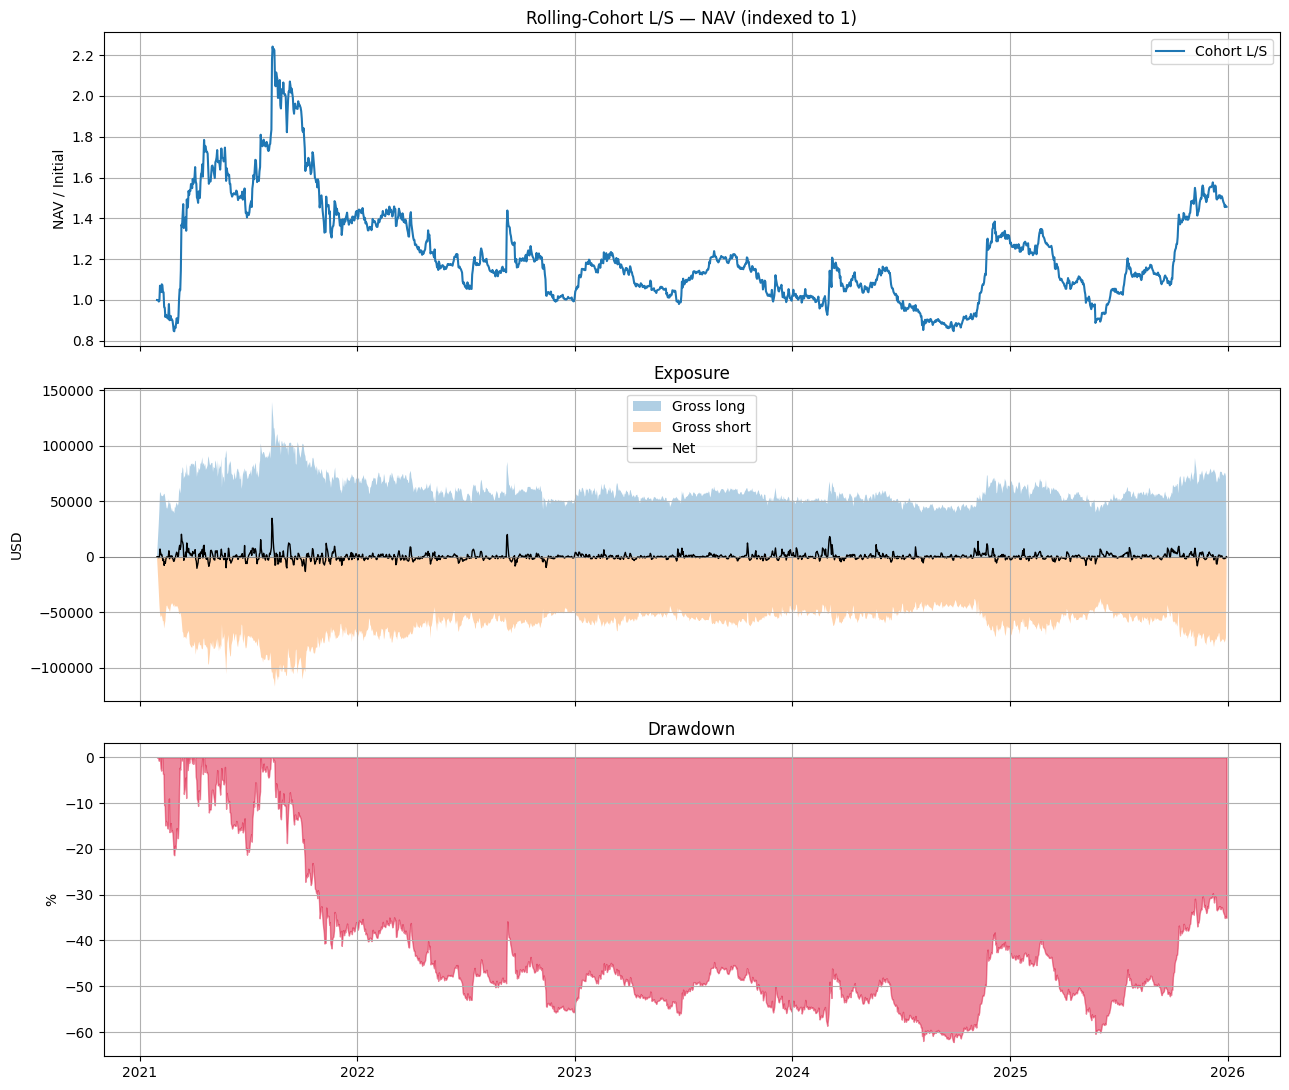

In [383]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# NAV
axes[0].plot(port_cohort['date'], port_cohort['nav'] / cfg.INITIAL_CAPITAL, label='Cohort L/S')
axes[0].set_title('Rolling-Cohort L/S — NAV (indexed to 1)')
axes[0].set_ylabel('NAV / Initial')
axes[0].legend(); axes[0].grid()

# Gross long / short / net
axes[1].fill_between(port_cohort['date'],  port_cohort['gross_long'],  alpha=0.35, label='Gross long')
axes[1].fill_between(port_cohort['date'], -port_cohort['gross_short'], alpha=0.35, label='Gross short')
axes[1].plot(port_cohort['date'],  port_cohort['net_exposure'], color='black', lw=1, label='Net')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_title('Exposure')
axes[1].set_ylabel('USD')
axes[1].legend(); axes[1].grid()

# Drawdown
dd_s = (port_cohort['nav'] / port_cohort['nav'].cummax()) - 1
axes[2].fill_between(port_cohort['date'], dd_s * 100, alpha=0.5, color='crimson')
axes[2].set_title('Drawdown')
axes[2].set_ylabel('%')
axes[2].grid()

plt.tight_layout()
plt.savefig('cohort_backtest.png', dpi=150, bbox_inches='tight')
plt.show()